# Select reservoirs and study period
***

**Author:** Chus Casado Rodríguez<br>
**Date:** 20/04/2026<br>

**Introduction:**<br>
This notebook reads all the attributes and time series in the dataset and selects the reservoirs appropriate for testing the different reservoir routines. Several conditions need to be met for a reservoir to be selected:

1. It must contain observed time series of the variables `inflow`, `storage` and `outflow`.
2. The longest period without gaps in those three time series needs to be longer than 4 years.
3. The bias between the observed inflow and outflow timeseries needs to be between 0.7 and 1.3.

These conditions are specified in the YML configuration file.

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.auto import tqdm
import pickle

from reservoirs_lshm.utils import DatasetConfig
from reservoirs_lshm import read_attributes, read_timeseries
from reservoirs_lshm.utils.timeseries import define_period

## Configuration

In [3]:
cfg = DatasetConfig('../dataset/config_ResOpsUS_v22.yml')

PATH_OUT = cfg.PATH_RESOPS / cfg.VERSION / 'selection'

variables = ['inflow', 'storage', 'outflow']

## Data

### Attributes

In [4]:
# import all tables of attributes
attributes = read_attributes(cfg.PATH_ATTRS, reservoirs=None)
print(f'{attributes.shape[0]} reservoirs in the attribute tables')

# keep only reservoirs with all observed variables
mask = attributes[[var.upper() for var in variables]].all(axis=1)
attributes = attributes[mask]
attributes.sort_index(axis=0, inplace=True)
print('{0} reservoirs include observed time series for all variables: {1}'.format(
    attributes.shape[0],
    ', '.join(variables)
))

# keep reservoirs that comply with the catchment area and total storage conditions
if cfg.MIN_AREA is not None:
    mask_area = attributes.CATCH_SKM >= cfg.MIN_AREA
    # attributes = attribut-es[mask_area]
    print('{0} reservoirs comply with the minimum catchment area: {1} km²'.format(
        mask_area.sum(),
        cfg.MIN_AREA
    ))
if cfg.MIN_VOL is not None:
    mask_volume = attributes.CAP_MCM >= cfg.MIN_VOL
    # attributes = attributes[mask_volume]
    print('{0} reservoirs comply with the minimum storage capacity: {1} hm3'.format(
        mask_volume.sum(),
        cfg.MIN_VOL
    ))

677 reservoirs in the attribute tables
284 reservoirs include observed time series for all variables: inflow, storage, outflow
268 reservoirs comply with the minimum catchment area: 50 km²
283 reservoirs comply with the minimum storage capacity: 10 hm3


In [5]:
# load GRanD
grand = gpd.read_file(cfg.PATH_GRAND / 'GRanD_dams_v1_3.shp')
grand.columns = grand.columns.str.lower()
grand.set_index('grand_id', inplace=True)
grand = grand.loc[attributes.index]

len(grand)

284

### Time series

In [6]:
# read time series
timeseries = read_timeseries(
    cfg.PATH_TS / 'csv',
    attributes.index, 
    variables=variables + ['precip_point', 'evapo_point']
)
print(f'{len(timeseries)} reservoirs with timeseries\n')

  0%|          | 0/284 [00:00<?, ?it/s]

File /mnt/c/Datasets/reservoirs/ResOpsUS/v2.2/time_series/csv/288.csv doesn't exist
283 reservoirs with timeseries



In [7]:
# remove reservoirs with excessively low degree of regulation
if cfg.MIN_DOR is not None:
    attributes['dor_yr'] = pd.Series({
        grand_id: attributes.loc[grand_id, 'CAP_MCM'] * 1e6 / (ts.inflow.mean() * 365 * 24 * 3600)
        if 'inflow' in ts.columns else np.nan
        for grand_id, ts in timeseries.items()}, 
        name='dor_yr')
    mask_dor = attributes['dor_yr'] > cfg.MIN_DOR
    # attributes = attributes[mask_dor]
    # timeseries = {grand_id: ts for grand_id, ts in timeseries.items() if mask_dor[grand_id]}
    print(f'{mask_dor.sum()} reservoirs comply with the minimum degre of regulation: {cfg.MIN_DOR} years')
if cfg.MIN_DOD is not None:
    attributes['dod_m'] = attributes['CAP_MCM'] / attributes['CATCH_SKM']
    mask_dod = attributes['dod_m'] > cfg.MIN_DOD
    print(f'{mask_dod.sum()} reservoirs comply with the minimum degre of disruptivity: {cfg.MIN_DOD} m')

266 reservoirs comply with the minimum degre of regulation: 0.08 years
222 reservoirs comply with the minimum degre of disruptivity: 0.06 m


## Selection

In [8]:
bias = {}
periods = {}
mask_duration = pd.Series(False, index=attributes.index, dtype=bool)
mask_bias = mask_duration.copy()
for grand_id, ts in tqdm(timeseries.items(), desc='select reservoirs', total=len(timeseries)):
    
    # select study period
    start, end = define_period(ts[variables + ['precip_point', 'evapo_point']])
    if np.isnan(start) or np.isnan(end):
        print(f'{grand_id:>4} discarded for lack of records')
        continue
    duration = (end - start) / np.timedelta64(1, 'D')
    if duration >= cfg.MIN_YEARS * 365:
        mask_duration[grand_id] = True
        ts = ts.loc[start:end]
    else:
        print(f'{grand_id:>4} discarded for lack of records:\t{duration:.0f} days')
        continue
        
    # bias between inflow and outflow
    bias[grand_id] = ts.outflow.mean() / ts.inflow.mean()
    if (1 - cfg.TOL_BIAS) <= bias[grand_id] <= (1 + cfg.TOL_BIAS):
        mask_bias[grand_id] = True
        # save periods
        periods[str(grand_id)] = {
            'start_dates': [pd.Timestamp(start)],
            'end_dates': [pd.Timestamp(end)]
        }
    else:
        print(f'{grand_id:>4} discarded for excesive bias:\t{bias[grand_id]:.2f}')
    
print(f'\n{len(periods)} reservoirs selected')

select reservoirs:   0%|          | 0/283 [00:00<?, ?it/s]

  78 discarded for lack of records:	352 days
 111 discarded for lack of records:	348 days
 113 discarded for lack of records:	359 days
 114 discarded for excesive bias:	0.46
 135 discarded for lack of records:	1 days
 138 discarded for lack of records:	2 days
 144 discarded for lack of records:	1362 days
 158 discarded for lack of records:	1325 days
 163 discarded for excesive bias:	0.00
 173 discarded for lack of records:	381 days
 185 discarded for excesive bias:	0.62
 190 discarded for lack of records:	1115 days
 203 discarded for lack of records:	124 days
 204 discarded for excesive bias:	0.51
 210 discarded for excesive bias:	0.48
 223 discarded for lack of records:	863 days
 295 discarded for lack of records:	975 days
 299 discarded for lack of records
 320 discarded for lack of records:	882 days
 338 discarded for lack of records:	513 days
 347 discarded for lack of records:	10 days
 374 discarded for lack of records:	1445 days
 382 discarded for lack of records:	439 days
 385 d

In [9]:
# all conditions but regulation
mask_wo_regulation = mask_area & mask_volume & mask_duration & mask_bias
print(f'{mask_wo_regulation.sum()} out of {len(mask_wo_regulation)} reservoirs comply with all selection criteria ')

176 out of 284 reservoirs comply with all selection criteria 


In [10]:
# all conditions
mask_all = mask_wo_regulation & mask_dor # & mask_dod
print(f'{mask_all.sum()} out of {len(mask_all)} reservoirs comply with all selection criteria ')

164 out of 284 reservoirs comply with all selection criteria 


In [11]:
# reservoirs that comply with all criteria except regulation
difference = (mask_wo_regulation != mask_all)
grand.loc[difference, 'main_use'].value_counts()

main_use
Irrigation          4
Hydroelectricity    3
Navigation          3
Other               1
Flood control       1
Name: count, dtype: int64

In [12]:
# main use of all reservoirs that comply with all criteria
grand.loc[mask_all, 'main_use'].value_counts()

main_use
Flood control       66
Irrigation          54
Hydroelectricity    20
Water supply        17
Navigation           4
Recreation           1
Name: count, dtype: int64

In [13]:
masks = {
    'area': mask_area,
    'volume': mask_volume,
    'duration': mask_duration,
    'bias': mask_bias,
    'dor_yr': mask_dor,
    'dod_m': mask_dod
}
for name, mask in masks.items():
    print(f'{mask.sum()}/{len(mask)} reservoirs comply with the {name} criterion')

268/284 reservoirs comply with the area criterion
283/284 reservoirs comply with the volume criterion
210/284 reservoirs comply with the duration criterion
183/284 reservoirs comply with the bias criterion
266/284 reservoirs comply with the dor_yr criterion
222/284 reservoirs comply with the dod_m criterion


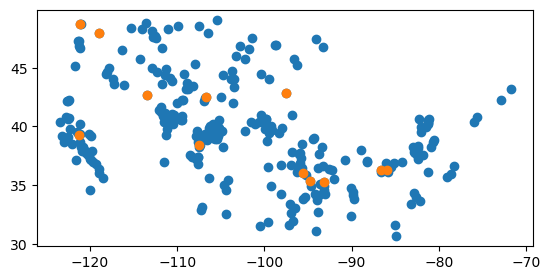

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
grand.plot(ax=ax)
grand.loc[difference].plot(ax=ax);

In [ ]:
(mask & mask_dod).sum()

In [ ]:
# # manually remove some reservoirs
# remove_reservoirs = []
# periods = {grand_id: period for grand_id, period in periods.items() if grand_id not in remove_reservoirs}

### Export

In [ ]:
# export list of selected reservoirs
with open(PATH_OUT / 'reservoirs.txt', 'w') as f:
    for grand_id in periods.keys():
        f.write(f'{grand_id}\n')

In [ ]:
# export selected study period
with open(PATH_OUT / 'periods.pkl', 'wb') as f:
    pickle.dump(periods, f)